## Assignment: Centrality Measures
### GitHub Developer Social Network (MUSAE) Data Loading & Simple EDA
DATA-620, Web Analytics, Fall 2026

Supervised by: **Professor Alain Ledon**


Submitted by: **Mehreen Ali Gillani**

**Dataset:** SNAP/MUSAE GitHub Social Network  
**Source:** https://snap.stanford.edu/data/github-social.html  
**Citation:** Rozemberczki, Allen & Sarkar (2019), *Multi-scale Attributed Node Embedding*, arXiv:1909.13021

**Files used:**
- `musae_git_edges.csv` — edge list (`id_1`, `id_2`) → 289,003 mutual-follow edges
- `musae_git_target.csv` — node metadata (`id`, `name`, `ml_target`) → categorical label (0 = web developer, 1 = ML developer)
- `musae_git_features.json` — node features (not needed for centrality analysis, loaded for completeness)

**Goal of this notebook (proposal stage):** 

-   Load the raw files, build the graph, attach the categorical
-   Label to each node, and run a *quick* EDA 
-   Full centrality/statistical analysis will be performed in (Project 1).

### 1. Imports

In [10]:
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


### 2. Load the raw files

In [11]:
# Edge list: two columns, id_1 and id_2 (undirected mutual-follow relationship)
edges_df = pd.read_csv("git_web_ml/musae_git_edges.csv")

# Node target/category: id, username, ml_target (0 = web dev, 1 = ML dev)
target_df = pd.read_csv("git_web_ml/musae_git_target.csv")

# Node features: dict of {node_id: [list of feature ids]} -- large, optional for now
with open(f"git_web_ml/musae_git_features.json") as f:
    features_dict = json.load(f)

print("Edges shape:", edges_df.shape)
print("Target shape:", target_df.shape)
print("Number of nodes with features:", len(features_dict))
edges_df.head()


Edges shape: (289003, 2)
Target shape: (37700, 3)
Number of nodes with features: 37700


,id_1,id_2
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982


In [12]:
target_df.head()

,id,name,ml_target
0,0,Eiryyy,0
1,1,shawflying,0
2,2,JpMCarrilho,1
3,3,SuhwanCha,0
4,4,sunilangadi2,1


## 3. Build the graph and attach the categorical attribute

We build an undirected `networkx` graph from the edge list, then attach each node's
`ml_target` category (0 = web developer, 1 = ML developer) and username as node attributes,
so the label travels with the node for later centrality comparisons.


In [13]:
G = nx.from_pandas_edgelist(edges_df, source="id_1", target="id_2")

# Map id -> ml_target / name for quick lookup, then attach as node attributes
target_lookup = target_df.set_index("id")[["name", "ml_target"]].to_dict(orient="index")

nx.set_node_attributes(G, {n: v["name"] for n, v in target_lookup.items()}, name="name")
nx.set_node_attributes(G, {n: v["ml_target"] for n, v in target_lookup.items()}, name="ml_target")

print("Number of nodes in graph:", G.number_of_nodes())
print("Number of edges in graph:", G.number_of_edges())

# Sanity check on one node
sample_node = list(G.nodes)[0]
print("Sample node:", sample_node, G.nodes[sample_node])


Number of nodes in graph: 37700
Number of edges in graph: 289003
Sample node: 0 {'name': 'Eiryyy', 'ml_target': 0}


### 4. Simple EDA (high level only — full analysis is for Project 1)

ml_target
Web developer    27961
ML developer      9739
Name: count, dtype: int64


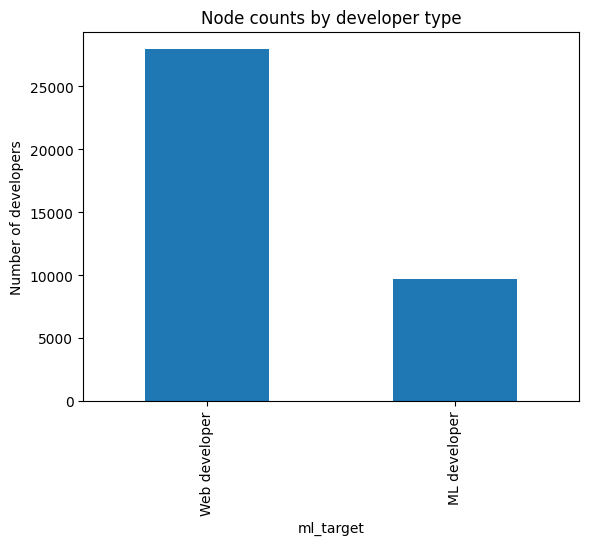

In [6]:
# Class balance of the categorical variable
label_map = {0: "Web developer", 1: "ML developer"}
class_counts = target_df["ml_target"].map(label_map).value_counts()
print(class_counts)

class_counts.plot(kind="bar", title="Node counts by developer type")
plt.ylabel("Number of developers")
plt.show()


Density: 0.0004066878203117068
count    37700.000000
mean        15.331724
std         80.788102
min          1.000000
25%          2.000000
50%          6.000000
75%         13.000000
max       9458.000000
Name: degree, dtype: float64


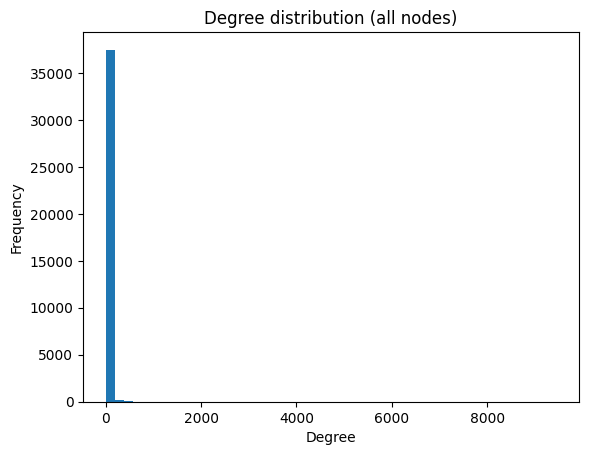

In [14]:
# Basic graph-level stats
print("Density:", nx.density(G))
degrees = dict(G.degree())
degree_series = pd.Series(degrees, name="degree")
print(degree_series.describe())

degree_series.plot(kind="hist", bins=50, title="Degree distribution (all nodes)")
plt.xlabel("Degree")
plt.show()


***NOTE***.    **Degree distribution is heavily skewed,** Stats shows it: std (80.8) is much larger than the mean (15.3), and max degree (9,458)

## 5. Quick peek at degree by category

This is just a light preview to confirm the categorical split is usable for centrality
comparison. 

The full degree-centrality / eigenvector-centrality computation and the
statistical test (t-test) across groups will be done in Project 1.


In [15]:
# Attach degree back to a dataframe with the category label for a quick group comparison
degree_df = degree_series.reset_index().rename(columns={"index": "id"})
merged_df = degree_df.merge(target_df, on="id")
merged_df["ml_target_label"] = merged_df["ml_target"].map(label_map)

merged_df.groupby("ml_target_label")["degree"].describe()


,count,mean,std,min,25%,50%,75%,max
ml_target_label,,,,,,,,
ML developer,9739.0,8.631687,22.253630,1.0,2.0,4.0,9.0,967.0
Web developer,27961.0,17.665391,92.771422,1.0,3.0,6.0,15.0,9458.0


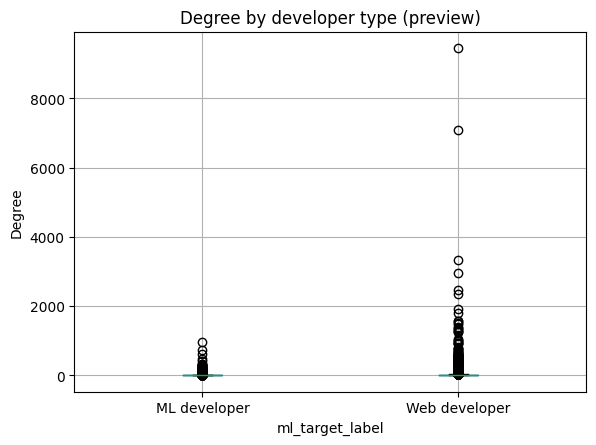

In [16]:
merged_df.boxplot(column="degree", by="ml_target_label")
plt.title("Degree by developer type (preview)")
plt.suptitle("")
plt.ylabel("Degree")
plt.show()
